# Stylized Facts of Returns: Heavy Tails
#### Scikit-Learn KDE on NVIDIA cuML

### Notebook Outline

**1 · Stylized Fact** — returns vs. the normal model (VaR / CAPM / Black-Scholes)  
**2 · Data** — intraday returns, 100 large-caps & ETFs; the bootstrap function  
**3 · Empirical v Normal** — emperical distribution vs. normal model, and the heavy tails  
**4 · KDE TL;DR** — a kernel bump on every observation, summed; built into scikit-learn  
**5 · CPU Benchmark** — CPU baseline  
**6 · NVIDIA cuML** — GPU-accelerated scikit-learn API  
**7 · CPU vs GPU Benchmark** — across sample sizes  
**8 · Next steps**  

**TL;DR — Run `%load_ext cuml.accel` before sklearn imports and `sklearn.neighbors.KernelDensity` runs on your NVIDIA GPU.** 

Notebook rendered with **AMD Threadripper PRO 7965WX** CPU with 48 threads and **NVIDIA RTX PRO 6000 Blackwell (96GB)** GPU.  
 - CPU: **~6 minutes to run bootstrap****
 - GPU: **~seconds to run bootstrap****

## Install NVIDIA cuML and NVIDIA cuDF

```bash

uv pip install --extra-index-url=https://pypi.nvidia.com cuml-cu13 cudf-cu13
~ OR ~
# pip
pip install --extra-index-url=https://pypi.nvidia.com cuml-cu13 cudf-cu13
```

Requirements: an NVIDIA GPU with CUDA 12+ and a recent driver.
If using **CUDA 12**, change the above dependencies to **cuml-cu12 cudf-cu12**.
Pre-installed when a GPU is attached:
 - Google Colab
 - Kaggle
 - Google Colab Enterprise 

In [1]:
!nvidia-smi --query-gpu=name,driver_version,memory.total --format=csv,noheader
# CPU model (so the render self-documents the baseline hardware, not just the GPU):
!grep -m1 'model name' /proc/cpuinfo | cut -d: -f2 | sed 's/^ //'

NVIDIA RTX PRO 6000 Blackwell Workstation Edition, 580.105.08, 97887 MiB
AMD Ryzen Threadripper PRO 7965WX 24-Cores


# 1. The Stylized Fact — Returns Are Not Normal

 - **VaR**
 - **CAPM**
 - **Black-Scholes**
These model returns as a normal distribution. Real returns are *leptokurtic* (tall narrow peak) with **heavy tails**

A **kernel density estimate (KDE)** recovers the actual density from the data, no distribution assumed, and a **bootstrap band** (hundreds to thousands of KDE refits) shows how stable that estimate is. The refit loop's cost scales with *(samples × query-grid)* per fit.

# 2. Data: 5-Min Bar Returns for 100 Large Caps and Popular ETFs

**Feb 2 – Jun 3, 2026**

In [2]:
import pandas as pd
from pathlib import Path
import numpy as np
import time

# Pre-computed 5-minute returns [ticker, ret]
CANDIDATES = ["intraday_returns.parquet", "../data/intraday_returns.parquet"]
DATA_PATH = next((p for p in CANDIDATES if Path(p).exists()), CANDIDATES[0])

Path("images").mkdir(parents=True, exist_ok=True)  # figures save here

all_returns = pd.read_parquet(DATA_PATH)
display(all_returns.head())

print(f"{all_returns['ticker'].nunique()} tickers")
print(f"{len(all_returns):,} pooled 5-minute return observations")
print("window: Feb 2 – Jun 3, 2026  (~4 months of 5-minute bars)")
print(f"mean={all_returns['ret'].mean():.2e}  std={all_returns['ret'].std():.4f}  "
      f"min={all_returns['ret'].min():.3f}  max={all_returns['ret'].max():.3f}")
print("prep filter: |r| > 5% dropped as bad ticks (see data/consolidator_nbs/build_intraday_returns.py)")

,ticker,ret
0,AAPL,-0.000169
1,AAPL,0.000506
2,AAPL,-0.000599
3,AAPL,0.000899
4,AAPL,-0.000075


100 tickers
657,396 pooled 5-minute return observations
window: Feb 2 – Jun 3, 2026  (~4 months of 5-minute bars)
mean=5.18e-06  std=0.0023  min=-0.050  max=0.050
prep filter: |r| > 5% dropped as bad ticks (see data/consolidator_nbs/build_intraday_returns.py)


### The Bootstrap Function

Confidence bands come from **bootstrapping** --> resampling returns w/ replacement and refit the KDE multiple times, then read a band off the spread of those refits.  
Created a single function to perform the bootstrapping `bootstrap_kde()` that returns timing and density curves to be plotted.  
Single function for CPU and GPU for comparison.

In [3]:
from sklearn.neighbors import KernelDensity

N_BOOT_HEADLINE = 100   
N_BOOT = N_BOOT_HEADLINE
N_SAMPLES = 50_000
KDE_BANDWIDTH = 0.0002

# Fixed evaluation grid: +/- 2% in 5-minute return space.
GRID = np.linspace(-0.02, 0.02, 5000).reshape(-1, 1)

In [4]:
def bootstrap_kde(returns, n_samples=N_SAMPLES, n_boot=N_BOOT, bandwidth=KDE_BANDWIDTH, seed=0):
    """Bootstrap KDE of a return sample. Returns timing + density band."""
    densities = np.empty((n_boot, len(GRID)))

    t0 = time.perf_counter()
    for i in range(n_boot):
        sample = returns.sample(n=n_samples, replace=True).values.reshape(-1, 1)
        kde = KernelDensity(bandwidth=bandwidth, kernel="gaussian").fit(sample)
        densities[i] = np.exp(kde.score_samples(GRID))
    fit_seconds = time.perf_counter() - t0

    return {
        "fit_seconds": fit_seconds,
        "n_samples": n_samples,
        "n_boot": n_boot,
        "mean": densities.mean(axis=0),
        "lo": np.percentile(densities, 5, axis=0),
        "hi": np.percentile(densities, 95, axis=0),
    }

Run on CPU first 6-7 minutes on 48 Thread CPU

In [5]:
cpu_run = bootstrap_kde(all_returns['ret'], 
                        n_samples=N_SAMPLES, 
                        n_boot=N_BOOT_HEADLINE, 
                        bandwidth=KDE_BANDWIDTH)

print(f"KDE CPU: {cpu_run['fit_seconds']:.2f}s ({cpu_run['n_boot']} fits x {cpu_run['n_samples']:,} samples)")

KDE CPU: 391.02s (100 fits x 50,000 samples)


# 3. Returns vs. the Normal Model

The empirical density (KDE + bootstrap band) vs normal, and the ratio between them.  
The heavy tails are absent from the normal distribution.  
Reference: [Cont (2001), *Empirical properties of asset returns*](https://doi.org/10.1080/713665670)

In [6]:
import matplotlib.pyplot as plt
from scipy.stats import norm, kurtosis

plt.style.use("dark_background")
NV_GREEN, NV_BLUE, BAD_RED, AMBER = "#76b900", "#5eaeff", "#ff5e5e", "#ffb84d"

# Shared plot data: grid + the headline bootstrap result from Section 2.
_run = cpu_run
g = GRID.ravel()
g_pct = g * 100
mu = all_returns['ret'].mean()
sigma = all_returns['ret'].std()
gaussian = norm.pdf(g, loc=mu, scale=sigma)
mean, lo, hi = _run["mean"], _run["lo"], _run["hi"]
ratio = mean / np.clip(gaussian, 1e-300, None)

# Tail exceedance vs. the matched normal — count-based, no KDE/grid artifacts.
THRESH = 0.01
p_emp = (all_returns['ret'].abs() > THRESH).mean()
p_norm = norm.sf(THRESH, loc=mu, scale=sigma) + norm.cdf(-THRESH, loc=mu, scale=sigma)
tail_mult = p_emp / p_norm
print(f"|r| > 1% moves happen {tail_mult:,.0f}x more often than the matched normal predicts.")

|r| > 1% moves happen 667x more often than the matched normal predicts.


The bottom panel is **empirical / normal**  
How often each return value actually happens vs what the bell curve predicts.   

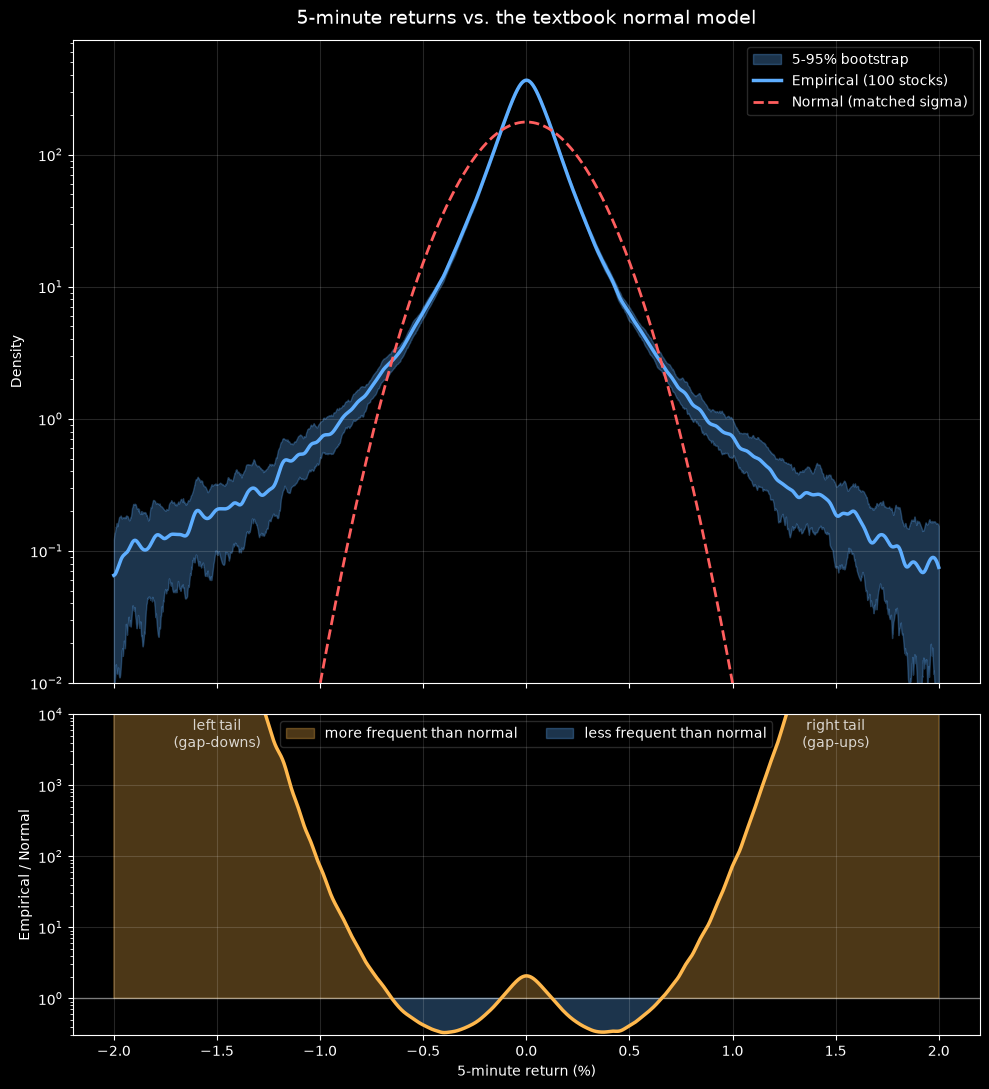

Excess kurtosis: 58.5   (normal = 0)
Largest move:    22.1 sigma   (pool pre-filtered to |r| <= 5%)
|r| > 1% moves happen 667x more often than the matched normal predicts.


In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 11), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})

# Top: density on a log scale so the tails are visible.
ax1.fill_between(g_pct, lo, hi, color=NV_BLUE, alpha=0.30, label="5-95% bootstrap")
ax1.plot(g_pct, mean, color=NV_BLUE, lw=2.5, label="Empirical (100 stocks)")
ax1.plot(g_pct, gaussian, color=BAD_RED, lw=2, ls="--", label="Normal (matched sigma)")
ax1.set_yscale("log")
ax1.set_ylim(0.01, mean.max() * 2)
ax1.set_ylabel("Density")
ax1.legend(loc="upper right", framealpha=0.2)
ax1.set_title("5-minute returns vs. the textbook normal model", fontsize=14, pad=12)
ax1.grid(alpha=0.15)

# Bottom: empirical / normal ratio, with left/right tail callouts.
ax2.axhline(1, color="white", lw=1, alpha=0.4)
ax2.plot(g_pct, ratio, color=AMBER, lw=2.5)
ax2.fill_between(g_pct, 1, ratio, where=(ratio > 1), color=AMBER, alpha=0.3, label="more frequent than normal")
ax2.fill_between(g_pct, 1, ratio, where=(ratio < 1), color=NV_BLUE, alpha=0.3, label="less frequent than normal")
ax2.annotate("left tail\n(gap-downs)", xy=(-1.5, min(ratio[g_pct < -1.5].max(), 9e3)), color="white", fontsize=10, ha="center", va="top", alpha=0.8)
ax2.annotate("right tail\n(gap-ups)", xy=(1.5, min(ratio[g_pct > 1.5].max(), 9e3)), color="white", fontsize=10, ha="center", va="top", alpha=0.8)

ax2.set_yscale("log")
ax2.set_ylim(0.3, 1e4)
ax2.set_ylabel("Empirical / Normal")
ax2.set_xlabel("5-minute return (%)")
ax2.legend(loc="upper center", framealpha=0.2, ncol=2)
ax2.grid(alpha=0.15)

plt.tight_layout()
plt.savefig("images/intraday_density_ratio.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

# Headline stylized-fact numbers.
exc_kurt = kurtosis(all_returns["ret"], fisher=True)
max_sigma = np.abs(all_returns["ret"]).max() / sigma
print(f"Excess kurtosis: {exc_kurt:.1f}   (normal = 0)")
print(f"Largest move:    {max_sigma:.1f} sigma   (pool pre-filtered to |r| <= 5%)")
print(f"|r| > 1% moves happen {tail_mult:,.0f}x more often than the matched normal predicts.")

# 4. KDE TL;DR

KDE places a small **bump** (kernel) on every observation and adds them up.  
Places with dense return counts stack into peaks.  
The rare returns keep their own bump out in the tails.  
The toy example below uses a handful of points for visualization.

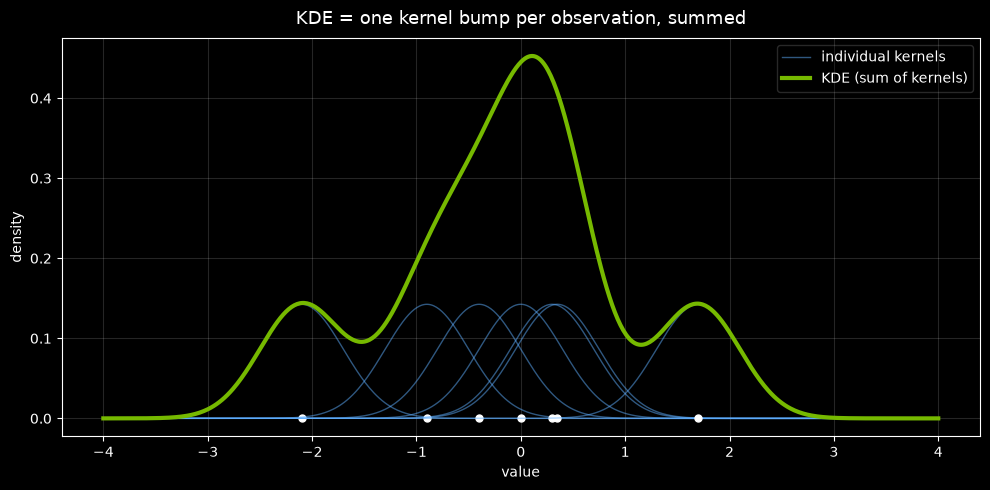

In [8]:
# Toy illustration: individual Gaussian kernels (thin) summing to the KDE (thick).
from sklearn.neighbors import KernelDensity as _KD

toy = np.array([-2.1, -0.9, -0.4, 0.0, 0.3, 0.35, 1.7])   # a few sample "returns"
bw = 0.4
xs = np.linspace(-4, 4, 600)

fig, ax = plt.subplots(figsize=(10, 5))

# Each observation's own kernel bump.
for j, x0 in enumerate(toy):
    bump = norm.pdf(xs, loc=x0, scale=bw) / len(toy)
    ax.plot(xs, bump, color=NV_BLUE, lw=1, alpha=0.5,
            label="individual kernels" if j == 0 else None)
    ax.plot([x0], [0], marker="o", color="white", ms=5)

# The KDE = sum of the bumps (via sklearn, so it matches the real method).
kde = _KD(bandwidth=bw, kernel="gaussian").fit(toy.reshape(-1, 1))
dens = np.exp(kde.score_samples(xs.reshape(-1, 1)))
ax.plot(xs, dens, color=NV_GREEN, lw=3, label="KDE (sum of kernels)")

ax.set_title("KDE = one kernel bump per observation, summed", fontsize=13, pad=10)
ax.set_xlabel("value")
ax.set_ylabel("density")
ax.legend(loc="upper right", framealpha=0.2)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.savefig("images/kde_kernels_explainer.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

### KDE is built into scikit-learn

Scikit-Learn's KDE: [`sklearn.neighbors.KernelDensity`](https://scikit-learn.org/stable/modules/density.html#kernel-density-estimation).  

# 5. CPU Benchmark Grid

Using CPU-only, sweep the sample size for the full baseline curve.  
Note the wall time based on workload size.  

In [9]:
SCALES = [10_000, 50_000, 100_000, 200_000]
N_BOOT = 1_000             # the workload the GPU grid runs in full
CPU_BOOT = 100             # CPU timed on fewer bootstraps, then scaled (time is linear in n_boot)


def time_sweep(pool, scales, n_boot, label, scale_to=None):
    """Time a KDE bootstrap sweep on the REAL return pool.
    If scale_to is set, linearly extrapolate fit time to that n_boot."""
    out = {}
    print(f"{label} grid ({n_boot} bootstraps"
          + (f", scaled to {scale_to})" if scale_to else ")") + ":")
    for n in scales:
        measured = bootstrap_kde(pool, n_samples=n, n_boot=n_boot)["fit_seconds"]
        out[n] = measured * (scale_to / n_boot) if scale_to else measured
        print(f"  n={n:>7,}: {out[n]:7.2f}s")
    return out


# CPU grid on the real pooled returns (scaled from CPU_BOOT -> N_BOOT).
cpu_grid = time_sweep(all_returns["ret"], SCALES, CPU_BOOT, "CPU", scale_to=N_BOOT)

# Anchor: one fully-measured CPU point at the full N_BOOT validates the linear scaling.
anchor_n = SCALES[0]
anchor_measured = bootstrap_kde(all_returns["ret"], n_samples=anchor_n, n_boot=N_BOOT)["fit_seconds"]
print(f"\nanchor (measured, full N_BOOT={N_BOOT}, n={anchor_n:,}): {anchor_measured:6.2f}s")
print(f"anchor (scaled  from CPU_BOOT={CPU_BOOT}):              {cpu_grid[anchor_n]:6.2f}s")
print(f"scaling error: {abs(anchor_measured - cpu_grid[anchor_n]) / anchor_measured:.1%}"
      "  (small -> linear-in-n_boot scaling is valid)")

CPU grid (100 bootstraps, scaled to 1000):
  n= 10,000:  289.56s
  n= 50,000: 3640.78s
  n=100,000: 8207.90s
  n=200,000: 18342.37s

anchor (measured, full N_BOOT=1000, n=10,000): 286.81s
anchor (scaled  from CPU_BOOT=100):              289.56s
scaling error: 1.0%  (small -> linear-in-n_boot scaling is valid)


# 6. GPU Acceleration w/ NVIDIA cuML
### <u>cuML</u> = <u>CU</u>DA-X for <u>M</u>achine <u>L</u>earning

https://developer.nvidia.com/topics/ai/data-science/cuda-x-data-science-libraries/cuml

### 6.1 Load `cuml.accel`

In a real session you would load this **before** your first sklearn import and run everything on the
GPU. Here it loads *after* the CPU run so both sides are measured in one pass.

In [11]:
# GPU acceleration for pandas, similar to cuml.accel for Scikit-Learn
%load_ext cudf.pandas

In [12]:
%load_ext cuml.accel

# Outside Notebooks/IPython: 
# import cuml.accel
# cuml.accel.install() 
# ~ or ~ 
# > python -m cuml.accel main.py

# Re-import so the cuml.accel-patched KernelDensity is used.
from sklearn.neighbors import KernelDensity

import pandas as pd
pd

<module 'pandas' (ModuleAccelerator(fast=cudf, slow=pandas))>

### 6.2 Same Scikit-Learn API on GPU

In [13]:
all_returns = pd.read_parquet(DATA_PATH)

# Same fit count as the CPU headline (pinned to N_BOOT_HEADLINE, immune to the Section-5
# N_BOOT override) so the speedup is apples-to-apples.
gpu_run = bootstrap_kde(all_returns["ret"], n_samples=N_SAMPLES, n_boot=N_BOOT_HEADLINE)
print(f"GPU bootstrap KDE: {gpu_run['fit_seconds']:.2f}s "
      f"({gpu_run['n_boot']} fits x {gpu_run['n_samples']:,} samples)")

GPU bootstrap KDE: 1.56s (100 fits x 50,000 samples)


### 6.3 GPU Speedup

In [14]:
speedup = cpu_run["fit_seconds"] / gpu_run["fit_seconds"]
print(f"CPU:     {cpu_run['fit_seconds']:7.2f}s")
print(f"GPU:     {gpu_run['fit_seconds']:7.2f}s")
print(f"Speedup: {speedup:7.1f}x")

CPU:      391.02s
GPU:        1.56s
Speedup:   251.0x


### 6.4 Validate CPU and GPU Result Agreement

GPU and CPU do not produce bit-identical numbers, but the recovered **density curves** should overlay.  
We check the max absolute difference relative to the peak density.  

In [15]:
rel_diff = np.abs(cpu_run["mean"] - gpu_run["mean"]).max() / cpu_run["mean"].max()
# Scientific notation: the difference is tiny but NONZERO — :.3% would round to a misleading "0.000%".
print(f"max relative difference between CPU and GPU density: {rel_diff:.2e}")
assert rel_diff < 0.05, "CPU and GPU densities diverge more than expected"
print("OK — CPU and GPU densities agree.")

max relative difference between CPU and GPU density: 1.77e-03
OK — CPU and GPU densities agree.


# 7. CPU vs GPU Benchmarks Across Sample Sizes

The CPU grid was timed in Section 5, before the NVIDIA cuML accelerator was loaded.   
Now run the **same sweep on the same data** on the GPU.  
**The larger the data, the more the GPU outperforms**  

### 7.1 GPU Grid

`cuml.accel` is loaded in Section 6, so the identical `time_sweep` now runs on the GPU.

In [16]:
gpu_grid = time_sweep(all_returns['ret'], SCALES, N_BOOT, "GPU")   # full N_BOOT on real returns — fast on GPU

GPU grid (1000 bootstraps):
  n= 10,000:    4.45s
  n= 50,000:   14.12s
  n=100,000:   25.85s
  n=200,000:   49.12s


### 7.2 Wall-Clock and Speedup

The speedup grows with sample size (more data per fit = more work to parallelize), so on this hardware it ranges from tens× at 10K samples to a few-hundred× at 200K.   
These are measured on a single machine. Results depend on your cuML, driver, GPU; and are not bit-identical run-to-run. 

In [17]:
import json

bench = pd.DataFrame({
    "n_samples": SCALES,
    "cpu_s": [cpu_grid[n] for n in SCALES],
    "gpu_s": [gpu_grid[n] for n in SCALES],
})
bench["speedup"] = bench["cpu_s"] / bench["gpu_s"]
print(bench.to_string(index=False))

# Persist for the reel chart (matches 02-lw-turnover's lw_timings_*.json convention).
Path("kde_timings.json").write_text(json.dumps({
    "scales": SCALES,
    "cpu_s": [cpu_grid[n] for n in SCALES],
    "gpu_s": [gpu_grid[n] for n in SCALES],
    "hardware": "Threadripper PRO 7965WX + RTX PRO 6000 Blackwell",
}, indent=2))
print("\nSaved kde_timings.json")

 n_samples        cpu_s     gpu_s    speedup
     10000   289.559859  4.452271  65.036436
     50000  3640.780933 14.116090 257.917092
    100000  8207.899056 25.848441 317.539418
    200000 18342.367587 49.118554 373.430525

Saved kde_timings.json


### 7.3 Benchmark Visual

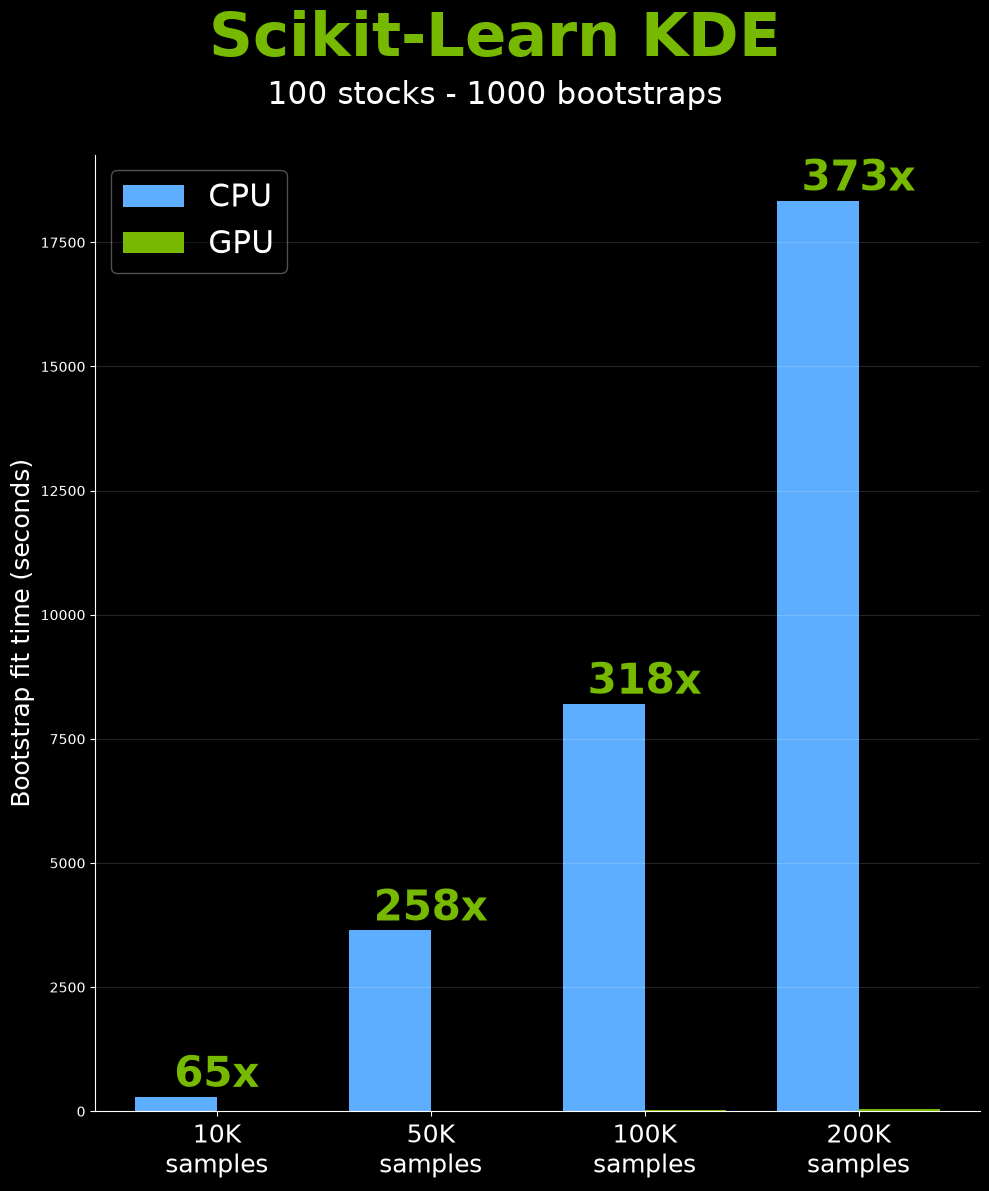

In [18]:
labels = ["10K", "50K", "100K", "200K"]
cpu_t = bench["cpu_s"].to_numpy()
gpu_t = bench["gpu_s"].to_numpy()
speedups = bench["speedup"].to_numpy()

fig, ax = plt.subplots(figsize=(10, 12), facecolor="black")
ax.set_facecolor("black")
x = np.arange(len(SCALES))
w = 0.38
ax.bar(x - w/2, cpu_t, w, color=NV_BLUE, label="CPU")
ax.bar(x + w/2, gpu_t, w, color=NV_GREEN, label="GPU")
for i, (c, s) in enumerate(zip(cpu_t, speedups)):
    if np.isfinite(s):
        ax.text(i, c, f"{s:.0f}x", ha="center", va="bottom",
                fontsize=30, fontweight="bold", color=NV_GREEN)
ax.set_xticks(x)
ax.set_xticklabels([f"{l}\nsamples" for l in labels], fontsize=18)
ax.set_ylabel("Bootstrap fit time (seconds)", fontsize=18)
ax.legend(fontsize=22, loc="upper left", framealpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.15)
fig.text(0.5, 0.95, "Scikit-Learn KDE", ha="center", fontsize=44, fontweight="bold", color=NV_GREEN)
fig.text(0.5, 0.91, f"100 stocks - {N_BOOT} bootstraps", ha="center", fontsize=22, color="white")
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig("images/kde_benchmark.png", dpi=200, facecolor="black", bbox_inches="tight")
plt.show()

# 8. Next Steps

- **Try it on Colab / Kaggle.** Attach a GPU, run `%load_ext cuml.accel` at the top, and the notebook runs on GPU since cuML and cuDF are pre-installed.  
- **Try other estimators.** The same `%load_ext cuml.accel` line accelerates many other sklearn estimators (`PCA`, `KMeans`, `SpectralClustering`, `LedoitWolf`, ...).

*Educational benchmark, not a trading strategy.*